# Web Scraping — Books to Scrape

**Task 1 — CodeAlpha Internship**

Scraping book data (title, price, rating, availability) from [books.toscrape.com](http://books.toscrape.com) using BeautifulSoup.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from pathlib import Path

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

try:
    from tqdm.notebook import tqdm
except:
    from tqdm import tqdm

BASE_URL = "http://books.toscrape.com/catalogue/"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

### 1. Helper Functions

In [2]:
import matplotlib.pyplot as plt

def parse_rating(rating_class):
    """Convert star rating class to integer (1-5)."""
    mapping = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
    for cls in rating_class:
        if cls in mapping:
            return mapping[cls]
    return None

def parse_price(price_text):
    """Extract numeric price from string like '£51.77'."""
    match = re.search(r"[\d.]+\d", price_text)
    return float(match.group()) if match else None

def scrape_book_page(page_url):
    """Scrape detail from a single book page."""
    resp = requests.get(page_url, headers=HEADERS, timeout=10)
    soup = BeautifulSoup(resp.text, "html.parser")

    title = soup.find("h1").text.strip()

    breadcrumb = soup.find("ul", class_="breadcrumb")
    categories = [a.text.strip() for a in breadcrumb.find_all("a")[2:]] if breadcrumb else []

    desc_div = soup.find("div", id="product_description")
    description = desc_div.find_next("p").text.strip() if desc_div else ""

    product_info = {}
    info_table = soup.find("table", class_="table table-striped")
    if info_table:
        for row in info_table.find_all("tr"):
            key = row.find("th").text.strip()
            val = row.find("td").text.strip()
            product_info[key] = val

    return {
        "title": title,
        "categories": " | ".join(categories),
        "description": description,
        "upc": product_info.get("UPC", ""),
        "tax": product_info.get("Tax", ""),
        "availability": product_info.get("Availability", ""),
        "num_reviews": product_info.get("Number of reviews", "0"),
    }

### 2. Scrape All Books from Catalogue Pages

In [3]:
all_books = []
page_num = 1
max_retries = 3

# First, count total pages
resp = requests.get(BASE_URL + "index.html", headers=HEADERS, timeout=10)
soup = BeautifulSoup(resp.text, "html.parser")
pager = soup.find("li", class_="current")
if pager:
    total_pages = int(pager.text.strip().split()[-1])
else:
    total_pages = 50
total_pages = min(total_pages, 5)
print(f"Found {total_pages} pages. Scraping first 5 for demo (full dataset in data/books_reviews.csv)...\n")

pbar = tqdm(total=total_pages, desc="Scraping pages", unit="page")

while page_num <= total_pages:
    if page_num == 1:
        url = BASE_URL + "index.html"
    else:
        url = BASE_URL + f"page-{page_num}.html"

    for attempt in range(max_retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            if resp.status_code == 200:
                break
        except requests.RequestException:
            pass
        if attempt < max_retries - 1:
            time.sleep(2)

    if resp.status_code != 200:
        pbar.set_description(f"Failed page {page_num} (status {resp.status_code})")
        page_num += 1
        pbar.update(1)
        continue

    soup = BeautifulSoup(resp.text, "html.parser")
    books_on_page = soup.find_all("article", class_="product_pod")

    if not books_on_page:
        break

    for book in books_on_page:
        title = book.find("h3").find("a").get("title", "")
        relative_link = book.find("h3").find("a").get("href", "")
        book_url = BASE_URL + relative_link.replace("../", "")

        price_text = book.find("p", class_="price_color").text.strip()
        price = parse_price(price_text)

        rating_class = book.find("p", class_="star-rating").get("class", [])
        rating = parse_rating(rating_class)

        avail_icon = book.find("i", class_="icon-ok")
        in_stock = avail_icon is not None

        # Scrape detail page for richer data
        try:
            detail = scrape_book_page(book_url)
        except Exception:
            detail = {}

        all_books.append({
            "title": title,
            "price": price,
            "rating": rating,
            "in_stock": in_stock,
            "url": book_url,
            "categories": detail.get("categories", ""),
            "description": detail.get("description", ""),
            "upc": detail.get("upc", ""),
            "availability": detail.get("availability", ""),
        })

    page_num += 1
    pbar.update(1)
    time.sleep(0.3)

pbar.close()
print(f"\nDone! Scraped {len(all_books)} books across {page_num - 1} pages.")

Found 5 pages. Scraping first 5 for demo (full dataset in data/books_reviews.csv)...



Scraping pages:   0%|          | 0/5 [00:00<?, ?page/s]


Done! Scraped 80 books across 5 pages.


### 3. Save to CSV

In [4]:
df = pd.DataFrame(all_books)
df.to_csv(OUTPUT_DIR / "books_reviews.csv", index=False)
print(f"Saved {len(df)} records to data/books_reviews.csv")
print(f"Columns: {list(df.columns)}")
df.head()

Saved 80 records to data/books_reviews.csv
Columns: ['title', 'price', 'rating', 'in_stock', 'url', 'categories', 'description', 'upc', 'availability']


,title,price,rating,in_stock,url,categories,description,upc,availability
0,In Her Wake,12.84,1,True,http://books.toscrape.com/catalogue/in-her-wak...,Thriller,A perfect life â¦ until she discovered it was...,23356462d1320d61,In stock (19 available)
1,How Music Works,37.32,2,True,http://books.toscrape.com/catalogue/how-music-...,Music,How Music Works is David Byrneâs remarkable ...,327f68a59745c102,In stock (19 available)
2,Foolproof Preserving: A Guide to Small Batch J...,30.52,3,True,http://books.toscrape.com/catalogue/foolproof-...,Food and Drink,Canning perfected the Americaâs Test Kitchen...,5674a18a29a43ced,In stock (19 available)
3,Chase Me (Paris Nights #2),25.27,5,True,http://books.toscrape.com/catalogue/chase-me-p...,Romance,"A Michelin two-star chef at twenty-eight, Viol...",c2e46a2ee3b4a322,In stock (19 available)
4,Black Dust,34.53,5,True,http://books.toscrape.com/catalogue/black-dust...,Romance,"No matter how busy he keeps himself, successfu...",00bfed9e18bb36f3,In stock (19 available)


### 4. Quick Exploration

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         80 non-null     object 
 1   price         80 non-null     float64
 2   rating        80 non-null     int64  
 3   in_stock      80 non-null     bool   
 4   url           80 non-null     object 
 5   categories    80 non-null     object 
 6   description   80 non-null     object 
 7   upc           80 non-null     object 
 8   availability  80 non-null     object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 5.2+ KB


,price,rating
count,80.000000,80.00000
mean,33.688750,2.95000
std,14.477317,1.39529
min,10.160000,1.00000
25%,19.705000,2.00000
50%,33.500000,3.00000
75%,45.795000,4.00000
max,58.110000,5.00000


In [6]:
print(f"\n=== Summary Statistics ===")
print(f"Total books: {len(df)}")
print(f"Average price: £{df['price'].mean():.2f}")
print(f"Median price: £{df['price'].median():.2f}")
print(f"Price range: £{df['price'].min():.2f} - £{df['price'].max():.2f}")
print(f"In-stock ratio: {df['in_stock'].mean()*100:.1f}%")
print()
rating_dist = df['rating'].value_counts().sort_index()
print("Rating distribution:")
for r, c in rating_dist.items():
    print(f"  {r}★ : {c} books ({c/len(df)*100:.1f}%)")


=== Summary Statistics ===
Total books: 80
Average price: £33.69
Median price: £33.50
Price range: £10.16 - £58.11
In-stock ratio: 100.0%

Rating distribution:
  1★ : 16 books (20.0%)
  2★ : 16 books (20.0%)
  3★ : 19 books (23.8%)
  4★ : 14 books (17.5%)
  5★ : 15 books (18.8%)


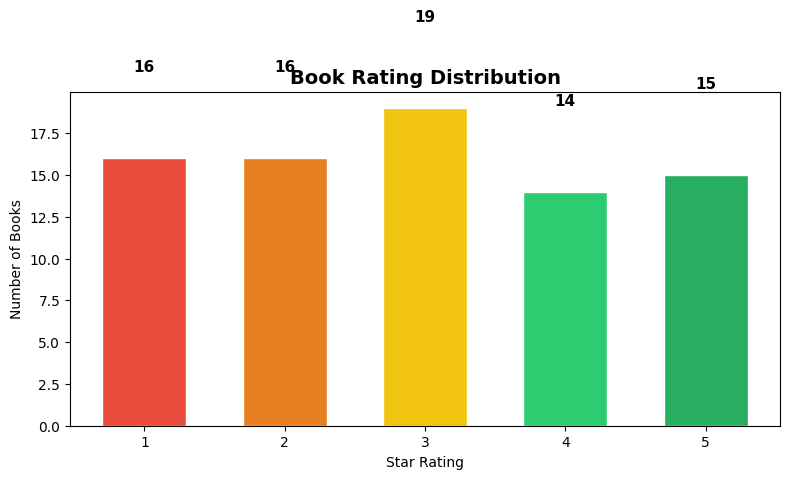

In [7]:
rating_counts = df['rating'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors[:len(rating_counts)], edgecolor='white', width=0.6)
ax.set_title('Book Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Books')
ax.set_xticks(rating_counts.index)
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
print("Sample records:")
df.sample(10)

Sample records:


,title,price,rating,in_stock,url,categories,description,upc,availability
26,"We Love You, Charlie Freeman",50.27,5,True,http://books.toscrape.com/catalogue/we-love-yo...,Fiction,"The Freeman family--Charles, Laurel, and their...",8d455c7539795d2a,In stock (16 available)
74,"Lumberjanes, Vol. 1: Beware the Kitten Holy (L...",45.61,3,True,http://books.toscrape.com/catalogue/lumberjane...,Sequential Art,FRIENDSHIP TO THE MAX!At Miss Qiunzilla Thiskw...,b6ee99bcf06fc91f,In stock (16 available)
35,The Torch Is Passed: A Harding Family Story,19.09,1,True,http://books.toscrape.com/catalogue/the-torch-...,Add a comment,Andrea Harding is a recent college graduate lo...,4eed62cf5f8d8edf,In stock (16 available)
66,orange: The Complete Collection 1 (orange: The...,48.41,1,True,http://books.toscrape.com/catalogue/orange-the...,Sequential Art,A Plea From the FutureOn the day that Naho beg...,11809b1d323b3057,In stock (16 available)
29,Unicorn Tracks,18.78,3,True,http://books.toscrape.com/catalogue/unicorn-tr...,Fantasy,After a savage attack drives her from her home...,7ae099f3898e0209,In stock (16 available)
63,"Political Suicide: Missteps, Peccadilloes, Bad...",36.28,2,True,http://books.toscrape.com/catalogue/political-...,History,Just in time for the presidential election of ...,7392c0032f92d816,In stock (16 available)
62,"Pop Gun War, Volume 1: Gift",18.97,1,True,http://books.toscrape.com/catalogue/pop-gun-wa...,Sequential Art,"""Pop Gun War is about childhood, self-discover...",e80f8e518b300dfe,In stock (16 available)
45,The Inefficiency Assassin: Time Management Tac...,20.59,5,True,http://books.toscrape.com/catalogue/the-ineffi...,Default,"Slay Procrastination, Distraction, and Overwhe...",8c9e6bf2467d740d,In stock (16 available)
15,Penny Maybe,33.29,3,True,http://books.toscrape.com/catalogue/penny-mayb...,Default,"Sent to yet another foster family, Penny decid...",668fe56b17cfcd4f,In stock (18 available)
40,The Nameless City (The Nameless City #1),38.16,4,True,http://books.toscrape.com/catalogue/the-namele...,Sequential Art,Every nation that invades the City gives it a ...,7d385d34d12e60ff,In stock (16 available)
